# check the scaling of the CCF thingy

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
import scanpy as sc
import matplotlib.pyplot as plt 
import pandas as pd
import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import processing, utils, plotting


In [2]:
allmeshes = utils.load_mesh()
allmeshes

{'250513_LC_core_67_mesh_shrunk': <trimesh.Trimesh(vertices.shape=(19148, 3), faces.shape=(38292, 3), name=`250513_LC_core_67_mesh_shrunk.obj`)>}

In [3]:


merfish_ccf = pd.read_csv('/home/shuonan.chen/scratch_shuonan/scripts/Pons_MERFISH/results_to_share/spatial_with_pseudocluster.csv')
pc = merfish_ccf['pseudocluster'].values

In [4]:
np.ptp(merfish_ccf[['AP', 'DV', 'ML']], 0)/1000

AP    1.042721
DV    3.960686
ML    1.893618
dtype: float64

In [6]:

ccf_merfish = merfish_ccf[['AP', 'DV', 'ML']].values
ccf_merfish = ccf_merfish/25
ccf_merfish_mm = utils.ccf_pts_convert_to_mm(ccf_merfish)
# ccf_merfish_mm = ccf_merfish/1000
bregma = np.array([216, 18, 228])

In [7]:
mesh = allmeshes['250513_LC_core_67_mesh_shrunk']
mesh_vertices = np.array(mesh.vertices)
mesh_vertices_mm = utils.ccf_pts_convert_to_mm(mesh_vertices)
ccf_center = np.mean(mesh_vertices_mm, axis=0)

In [8]:
ml, ap, dv = 0, 2, 1
ml_mesh, ap_mesh, dv_mesh = 2, 0, 1
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}
planes_mesh = {'sag': [ap_mesh, dv_mesh], 'hor': [ml_mesh, ap_mesh], 'cor': [ml_mesh, dv_mesh]}
filter_LC = ccf_merfish_mm[:, dv_mesh] < 4.7

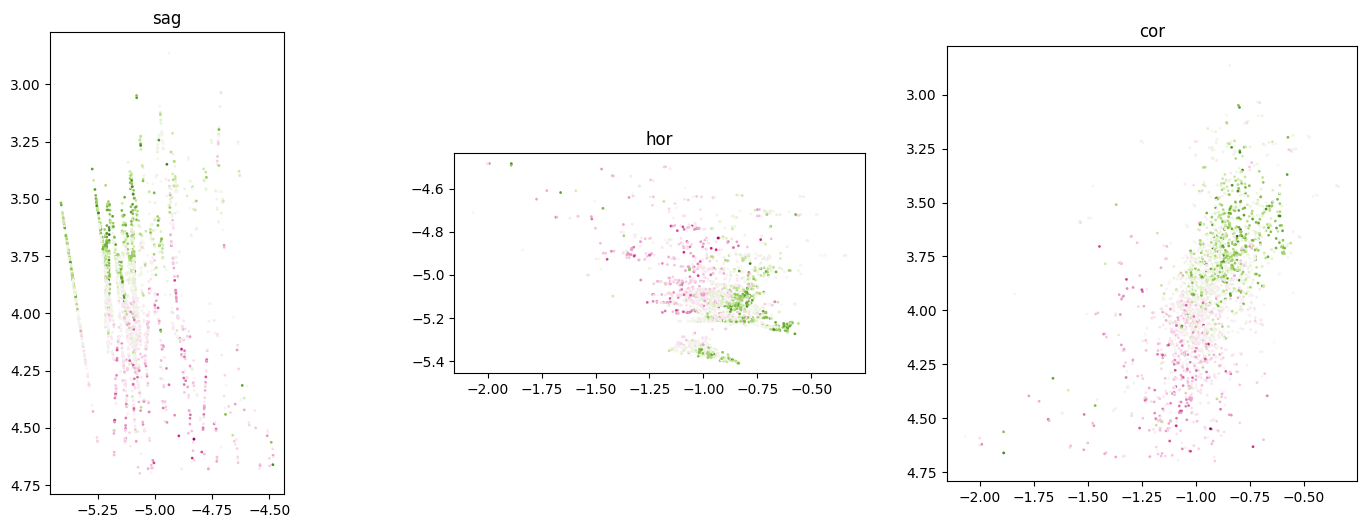

In [9]:

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 3)
for plane, ax_ind in zip(planes.keys(), range(3)):
    ax = fig.add_subplot(gs[ax_ind])
    # Plot the mesh
    # Plot the units with projection targets
#     ax.scatter(mesh_vertices_mm[:, planes_mesh[plane][0]], mesh_vertices_mm[:, planes_mesh[plane][1]], color='lightgray', alpha=0.7, s = 0.002)
    ax.scatter(ccf_merfish_mm[filter_LC, planes_mesh[plane][0]], ccf_merfish_mm[filter_LC, planes_mesh[plane][1]], 
               c = merfish_ccf[filter_LC]['pseudocluster'], cmap='PiYG', alpha=0.9, s = 1)
    ax.set_title(plane)
    if planes[plane][1] == dv:
        ax.invert_yaxis()
    ax.set_aspect(aspect='equal')

In [10]:
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
adata_mer =adata_mer[filter_LC]

In [11]:
adata_mer

View of AnnData object with n_obs × n_vars = 2213 × 315
    obs: 'slicename', 'x_CCF', 'y_CCF', 'z_CCF', 'mouse_name', 'mouse_sex', '_scvi_batch', '_scvi_labels', 'leiden', 'sex'
    uns: 'leiden_colors', 'mouse_name_colors', 'slicename_colors'
    obsm: 'X_scVI', 'X_umap', 'spatial'

In [12]:
ccf_merfish_mm.shape

(2651, 3)

In [13]:

scaler_X = StandardScaler().fit(adata_mer.X)
X_mer_scaled = scaler_X.transform(adata_mer.X)

S_mer = ccf_merfish_mm[filter_LC].copy()
scaler_S = StandardScaler().fit(S_mer)
S_mer_scaled = scaler_S.transform(S_mer)


In [14]:
n_components = 3
cca = CCA(n_components=n_components)
cca.fit(X_mer_scaled, S_mer_scaled)
X_c, S_c = cca.transform(X_mer_scaled, S_mer_scaled)
canonical_correlations = [np.corrcoef(X_c[:, i], S_c[:, i])[0, 1] for i in range(n_components)]
print("Canonical correlations:", canonical_correlations)

Canonical correlations: [0.9223837345655359, 0.8125684986416151, 0.6710095547812992]


In [15]:
cca.y_weights_

array([[ 0.99637878, -0.06931911, -0.04923602],
       [-0.07322585, -0.9938922 , -0.08256071],
       [-0.04321226,  0.08586709, -0.99536905]])

In [16]:
-cca.y_weights_[:,1]

array([ 0.06931911,  0.9938922 , -0.08586709])

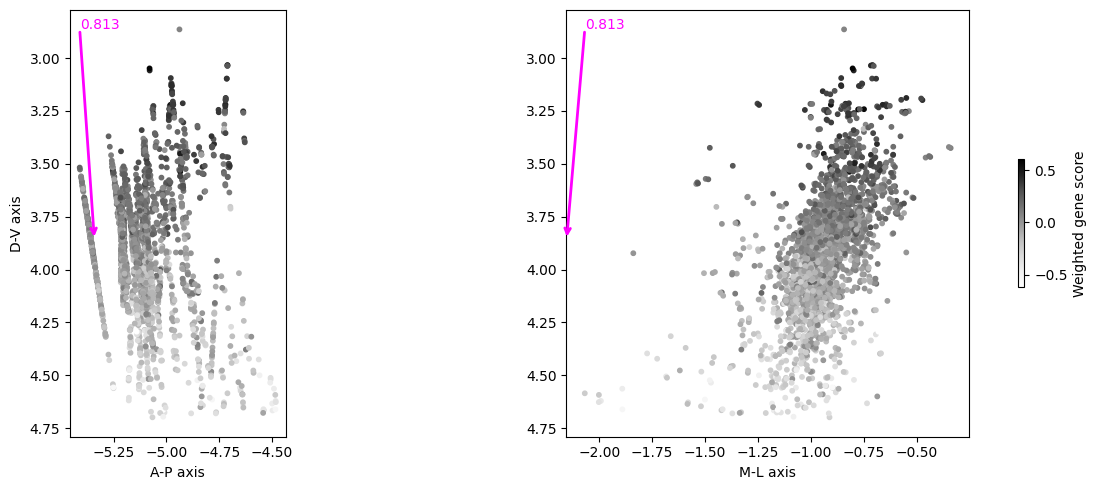

In [17]:
allspatial = ccf_merfish_mm[filter_LC].copy()

k = 1
scale_factor = -1 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * scale_factor

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    gridspec_kw={'width_ratios': [1, 4]}
)


ax1.scatter(allspatial[:, 0], allspatial[:, 1], c=X_c[:, k],cmap='Greys',s=10)
ax1.set_aspect('equal')

start_point_all = np.min(allspatial,0)
start_point = (start_point_all[0],start_point_all[1])
end_point = (start_point_all[0] + vector_scaled[0], start_point_all[1] + vector_scaled[1])

ax1.annotate('',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2))
ax1.text(start_point[0],start_point[1],np.around(canonical_correlations[k],3).astype(str), color = 'magenta')
ax1.invert_yaxis()
ax1.grid(False)
ax1.set_ylabel("D-V axis")
# ax1.set_yticks([])
# ax1.set_xticks([])
ax1.set_xlabel("A-P axis")
# ax1.set_xlim(-6,-4)
# ax1.set_ylim(5,2)



sca = ax2.scatter(
    allspatial[:, 2],
    allspatial[:, 1],
    c=X_c[:, k],
    cmap='Greys',
    s=10)
cbar = plt.colorbar(sca, ax=ax2, label='Weighted gene score', shrink=0.3)
ax2.set_aspect('equal')
start_point_all = np.min(allspatial,0)
start_point = (start_point_all[2],start_point_all[1])
end_point = (start_point_all[2] + vector_scaled[2], start_point_all[1] + vector_scaled[1])

# ax2.triplot(mesh.vertices.T[2], mesh.vertices.T[1], mesh.faces, alpha = .1, label = '67%')
ax2.annotate('',
#     "%.3f" %-canonical_correlations[k],color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2))
ax2.text(start_point[0],start_point[1],np.around(canonical_correlations[k],3).astype(str), color = 'magenta')

ax2.invert_yaxis()
ax2.grid(False)
# ax2.set_yticks([])
# ax2.set_xticks([])
ax2.set_xlabel("M-L axis")
# ax2.set_xlim(-3,0)
# ax2.set_ylim(5,2)

fig.tight_layout()
# plt.gcf().set_dpi(200) 
plt.show()

(-5.409841249094138, 2.8646244339939897) (-4.612738224216785, 2.8060437539437393)


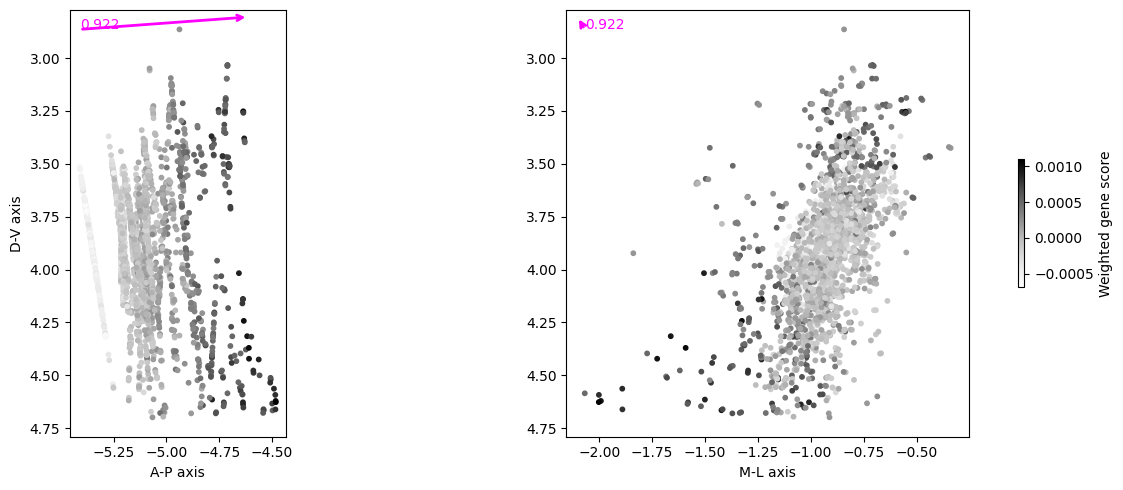

In [18]:
allspatial = ccf_merfish_mm[filter_LC].copy()

k = 0
scale_factor = .8 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * scale_factor

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    gridspec_kw={'width_ratios': [1, 4]}
)


ax1.scatter(allspatial[:, 0], allspatial[:, 1], c=X_c[:, k],cmap='Greys',s=10)
ax1.set_aspect('equal')

start_point_all = np.min(allspatial,0)
start_point = (start_point_all[0],start_point_all[1])
end_point = (start_point_all[0] + vector_scaled[0], start_point_all[1] + vector_scaled[1])
print(start_point, end_point)
ax1.annotate('',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2))
ax1.text(start_point[0],start_point[1],np.around(canonical_correlations[k],3).astype(str), color = 'magenta')
ax1.invert_yaxis()
ax1.grid(False)
ax1.set_ylabel("D-V axis")
# ax1.set_yticks([])
# ax1.set_xticks([])
ax1.set_xlabel("A-P axis")
# ax1.set_xlim(-6,-4)
# ax1.set_ylim(5,2)



sca = ax2.scatter(
    allspatial[:, 2],
    allspatial[:, 1],
    c=X_c[:, k],
    cmap='Greys',
    s=10)
cbar = plt.colorbar(sca, ax=ax2, label='Weighted gene score', shrink=0.3)
ax2.set_aspect('equal')
start_point_all = np.min(allspatial,0)
start_point = (start_point_all[2],start_point_all[1])
end_point = (start_point_all[2] + vector_scaled[2], start_point_all[1] + vector_scaled[1])

# ax2.triplot(mesh.vertices.T[2], mesh.vertices.T[1], mesh.faces, alpha = .1, label = '67%')
ax2.annotate('',
#     "%.3f" %-canonical_correlations[k],color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2))
ax2.text(start_point[0],start_point[1],np.around(canonical_correlations[k],3).astype(str), color = 'magenta')

ax2.invert_yaxis()
ax2.grid(False)
# ax2.set_yticks([])
# ax2.set_xticks([])
ax2.set_xlabel("M-L axis")
# ax2.set_xlim(-3,0)
# ax2.set_ylim(5,2)

fig.tight_layout()
# plt.gcf().set_dpi(200) 
plt.show()

In [170]:
start_point

(-2.068608102805558, 2.8646244339939897)

In [171]:
end_point

(-2.111820363346724, 2.7913985839266044)

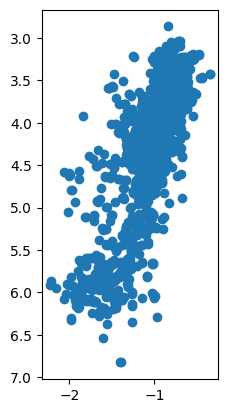

In [20]:
plt.scatter(ccf_merfish_mm[:,2],ccf_merfish_mm[:,1])
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import trimesh
import plotly.express as px
import plotly.graph_objects as go
import os,glob,sys
from plotly.subplots import make_subplots
from pprint import pprint

In [3]:
import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
mesh_CD = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCD_ccf_v1_250102 2.obj")
mesh_CV = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCV_ccf_v1_250102 2.obj")
allmeshes = [mesh_LC,mesh_CD,mesh_CV]

In [6]:
df = pd.read_csv("/home/shuonan.chen/scratch_shuonan/scripts/Pons_MERFISH/results_to_share/dbh_pos_cells_all_OLD.csv", sep='\t', dtype={0: str})
df.shape

In [33]:
import anndata as ad
ccf_columns = [col for col in df.columns if "CCF" in col]  # CCF columns
obs_columns = ["neuron_id", "slicename"] + ccf_columns  # Include slicename in obs

columns_to_exclude = [col for col in df.columns if "Blank" in col] + ccf_columns + ["slicename"]
df_filtered = df.drop(columns=columns_to_exclude)
df_filtered.set_index("neuron_id", inplace=True)

adata_mer = ad.AnnData(df_filtered)
adata_mer.obs = df[obs_columns].set_index("neuron_id")
adata_mer.obsm['spatial'] = adata_mer.obs[['x_CCF','y_CCF','z_CCF']].values
adata_mer.obs['totalcounts'] = np.sum(adata_mer.X,1)
allmousenames = ['MouseC','MouseF','MouseEg','MouseZM']
section_identifier_highlevel = [next(mouse for mouse in allmousenames if mouse in name)
                                for name in adata_mer.obs.slicename]    
adata_mer.obs['mouse_name'] = section_identifier_highlevel
adata_mer=adata_mer[~np.isnan(adata_mer.obs['x_CCF'].values)]
# adata_mer.X /= adata_mer.obs['totalcounts'][:,None]

/scratch/fast/213694/ipykernel_320825/2531116599.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_mer.obs['Dbh'] = np.array(adata_mer[:,'Dbh'].X).flatten()


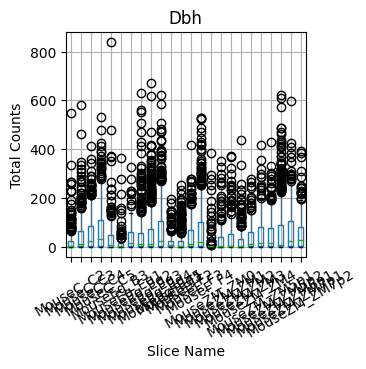

In [34]:
adata_mer.obs['Dbh'] = np.array(adata_mer[:,'Dbh'].X).flatten()
adata_mer.obs.boxplot(column='Dbh', by='slicename', figsize=(3,3))
plt.suptitle('')  
plt.xlabel('Slice Name')
plt.ylabel('Total Counts')
plt.xticks(rotation = 30)
plt.show()


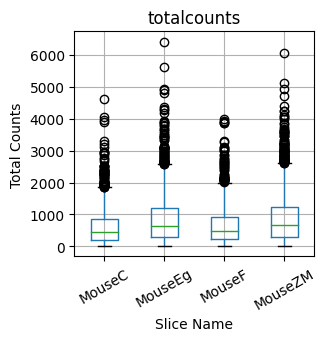

In [35]:
adata_mer.obs.boxplot(column='totalcounts', by='mouse_name', figsize=(3,3))
plt.suptitle('')  
plt.xlabel('Slice Name')
plt.ylabel('Total Counts')
plt.xticks(rotation = 30)
plt.show()


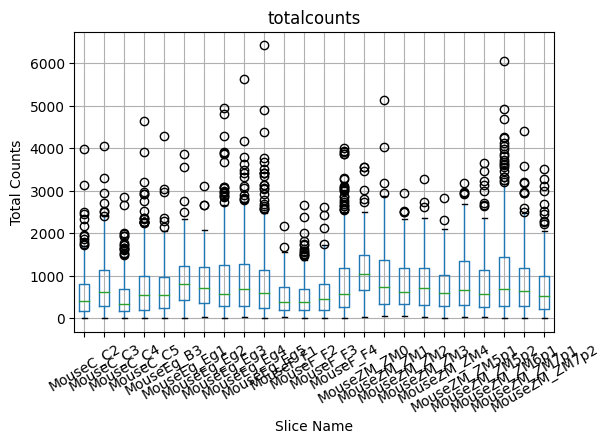

In [36]:
adata_mer.obs.boxplot(column='totalcounts', by='slicename', figsize=(6,4))
plt.suptitle('')  
plt.xlabel('Slice Name')
plt.ylabel('Total Counts')
plt.xticks(rotation = 30)
plt.show()


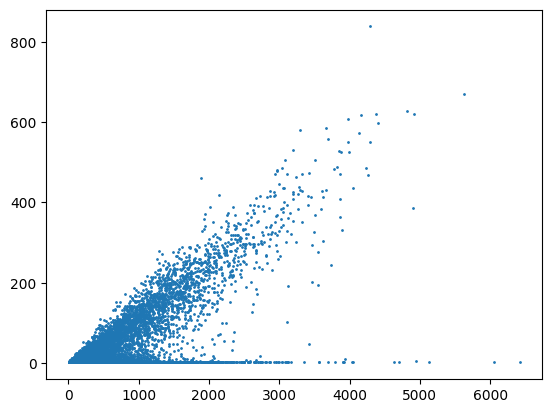

In [37]:
plt.scatter(adata_mer.obs['totalcounts'], adata_mer.obs['Dbh'], s=1)

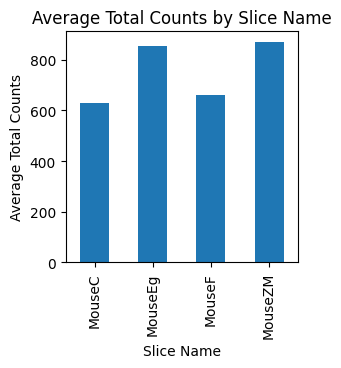

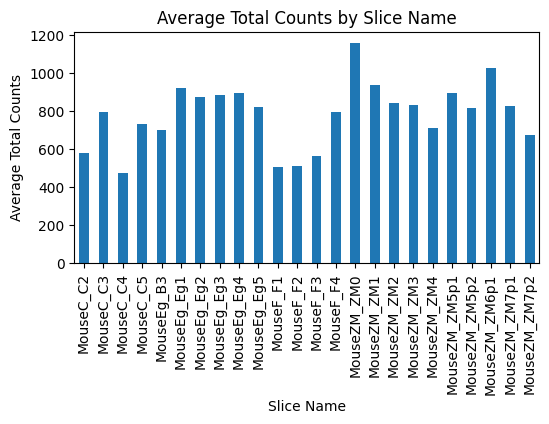

In [38]:

grouped_means = adata_mer.obs.groupby('mouse_name')['totalcounts'].mean()
grouped_means.plot(kind='bar', figsize=(3,3))
plt.title('Average Total Counts by Slice Name')
plt.xlabel('Slice Name')
plt.ylabel('Average Total Counts')
plt.show()


grouped_means = adata_mer.obs.groupby('slicename')['totalcounts'].mean()
grouped_means.plot(kind='bar', figsize=(6,3))
plt.title('Average Total Counts by Slice Name')
plt.xlabel('Slice Name')
plt.ylabel('Average Total Counts')
plt.show()


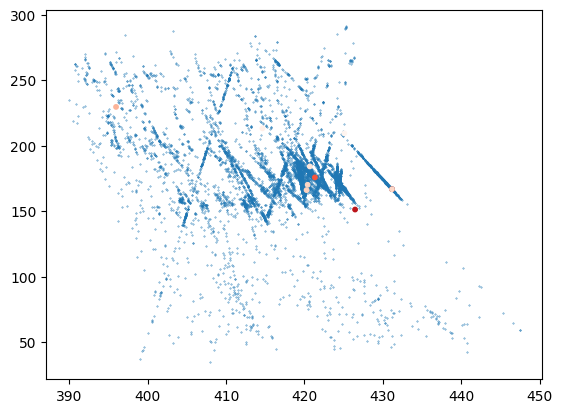

In [39]:
filteredcells = (adata_mer.obs['totalcounts'] >adata_mer.obs['totalcounts'].max()*0.7)
plt.scatter(adata_mer.obs['x_CCF'], adata_mer.obs['y_CCF'],s=.1) 
#             c = adata_mer.obs['totalcounts'], s=4, cmap = 'jet')

plt.scatter(adata_mer.obs['x_CCF'][filteredcells], adata_mer.obs['y_CCF'][filteredcells], 
            c = adata_mer.obs['totalcounts'][filteredcells], s=10, cmap = 'Reds')
# plt.gca().set_aspect('equal')

## cca with some arbitrary normalization 
- do we stil see this CCA1 effect when normalizign within sections/mice? 

In [40]:
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler


In [41]:
def flip(a, xm):
        return(2*xm-a)

def get_hemi(S_mer, mesh):
    '''
    assume the axis of interest are both on the last axis. 
    '''
    xm = np.min(mesh.vertices[:,-1]) + np.ptp(mesh.vertices[:,-1])/2 # this is the center line to indicate the hemisphere 
    new_coords = S_mer.copy()
    new_coords[:,-1] = np.where(new_coords[:,-1] > xm, flip(new_coords[:,-1],xm), new_coords[:,-1])    
    return(new_coords)



In [42]:
def run_CCA(adata, mesh_LC,n_components=3,visualize = False):
    X_mer = adata.X        # Gene expression matrix (2800 x 314)
    S_mer = adata.obsm['spatial']  # Spatial coordinates matrix, e.g., (2800 x 2)
    S_mer = get_hemi(S_mer, mesh_LC)    
    scaler_X = StandardScaler().fit(X_mer)
    X_mer_scaled = scaler_X.transform(X_mer)
    scaler_S = StandardScaler().fit(S_mer)
    S_mer_scaled = scaler_S.transform(S_mer)
    
    if visualize:
        plt.figure(figsize = (5,5))
        plt.scatter(S_mer[:,2], S_mer[:,1],s=.3, alpha =.8);
        plt.gca().set_aspect('equal')
        plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        plt.gca().invert_yaxis()
        
    cca = CCA(n_components=n_components)
    cca.fit(X_mer_scaled, S_mer_scaled)
    X_c, S_c = cca.transform(X_mer_scaled, S_mer_scaled)

    return(cca, X_c, S_c)

Canonical correlations: [0.8119033744075373, 0.6861114539502998, 0.474301668555401]


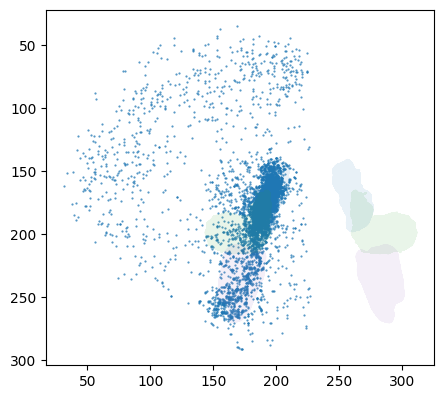

In [43]:
n_components = 3
cca, X_c, S_c = run_CCA(adata_mer, mesh_LC,n_components=n_components, visualize=True)
canonical_correlations = [np.corrcoef(X_c[:, i], S_c[:, i])[0, 1] for i in range(n_components)]
print("Canonical correlations:", canonical_correlations)

r2 = canonical_correlations.copy()

In [44]:
canonical_correlations

[0.8119033744075373, 0.6861114539502998, 0.474301668555401]

In [45]:
[-cca.y_weights_[:,k] for k in range(3)]

[array([-0.00549096,  0.46247773,  0.8866139 ]),
 array([ 0.00437746, -0.88660765,  0.46250158]),
 array([-0.99997534, -0.0064207 , -0.00284385])]

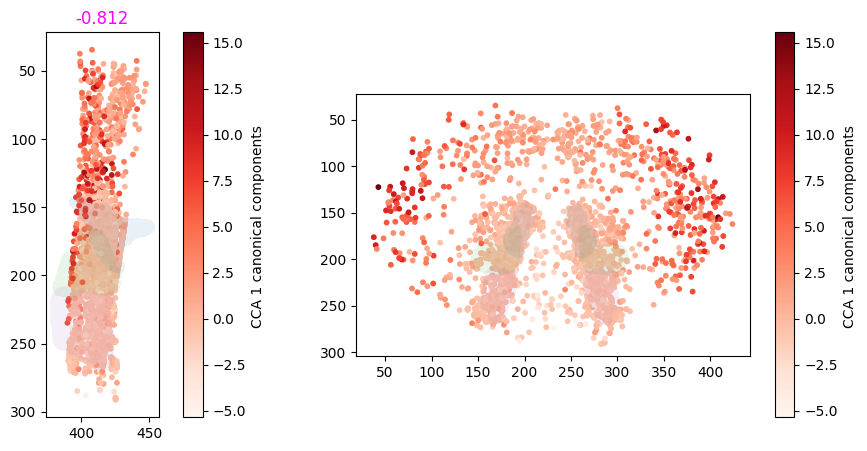

<Figure size 640x480 with 0 Axes>

In [46]:
k = 0
scale_factor =50 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * -scale_factor

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sca = plt.scatter(adata_mer.obsm['spatial'][:, 0], adata_mer.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()
plt.title("%.3f" %-canonical_correlations[k], color = 'magenta')

start_point = (np.min(adata_mer.obsm['spatial'][:, 0]), np.max(adata_mer.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[0], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )


plt.subplot(1,2,2)
sca = plt.scatter(adata_mer.obsm['spatial'][:, 2], adata_mer.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()

start_point = (np.min(adata_mer.obsm['spatial'][:, 2]), np.max(adata_mer.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[2], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )


plt.show()
plt.tight_layout()

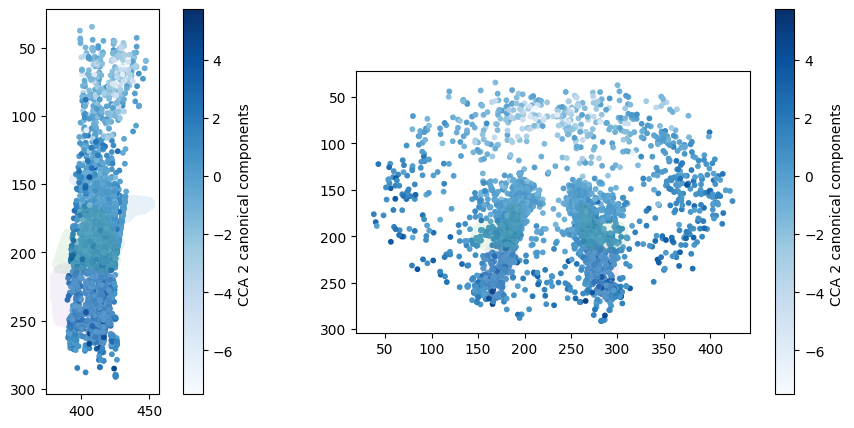

<Figure size 640x480 with 0 Axes>

In [47]:
k = 1
scale_factor = 50 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * -scale_factor

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sca = plt.scatter(adata_mer.obsm['spatial'][:, 0], adata_mer.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')
plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()
start_point = (np.min(adata_mer.obsm['spatial'][:, 0]), np.min(adata_mer.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[0], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )


plt.subplot(1,2,2)
sca = plt.scatter(adata_mer.obsm['spatial'][:, 2], adata_mer.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.title("" %-canonical_correlations[k])
start_point = (np.min(adata_mer.obsm['spatial'][:, 2]), np.min(adata_mer.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[2], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )

plt.gca().invert_yaxis()

plt.show()
plt.tight_layout()

In [52]:
vector

array([0.99997534, 0.0064207 , 0.00284385])

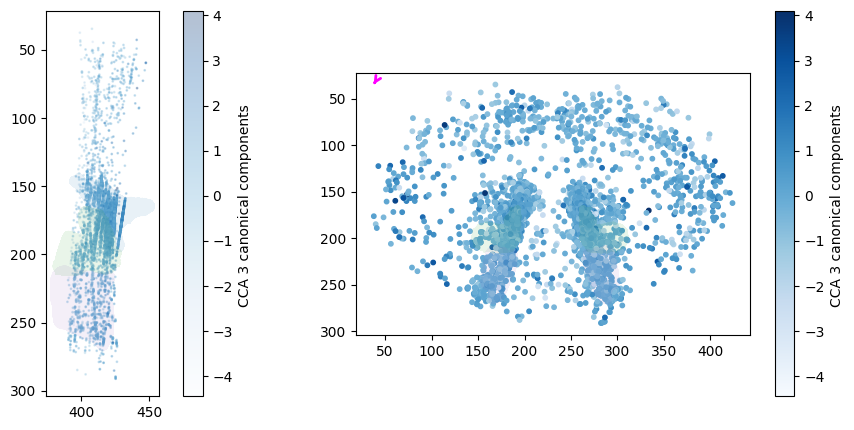

<Figure size 640x480 with 0 Axes>

In [50]:
k = 2
scale_factor = 50 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * -scale_factor

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sca = plt.scatter(adata_mer.obsm['spatial'][:, 0], adata_mer.obsm['spatial'][:, 1], 
                  c=X_c[:, k],cmap='Blues',s=1, alpha = .3)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')
plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()
start_point = (np.min(adata_mer.obsm['spatial'][:, 0]), np.min(adata_mer.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[0], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )



plt.subplot(1,2,2)
sca = plt.scatter(adata_mer.obsm['spatial'][:, 2], adata_mer.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.title("" %-canonical_correlations[k])
start_point = (np.min(adata_mer.obsm['spatial'][:, 2]), np.min(adata_mer.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[2], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )

plt.gca().invert_yaxis()

plt.show()
plt.tight_layout()

# lets filter out the 2.6 k cells (but not including teh BN results)


In [ ]:

adata_mer.obs.index


In [ ]:
import scanpy as sc
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adatafoo = sc.read_h5ad(filename)
neu_ids = adatafoo.obs.index

In [118]:
adata_mer_sm= adata_mer[neu_ids]

In [119]:
adata_mer_sm

View of AnnData object with n_obs × n_vars = 2651 × 315
    obs: 'slicename', 'x_CCF', 'y_CCF', 'z_CCF', 'totalcounts', 'mouse_name'
    obsm: 'spatial'

Canonical correlations: [0.9063820218255265, 0.5760566233558845, 0.5009949508879946]


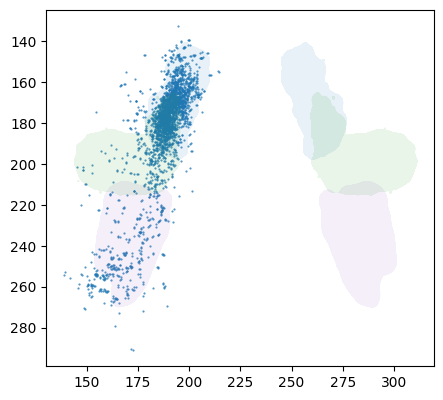

In [120]:
n_components = 3
cca, X_c, S_c = run_CCA(adata_mer_sm, mesh_LC,n_components=n_components, visualize=True)
canonical_correlations = [np.corrcoef(X_c[:, i], S_c[:, i])[0, 1] for i in range(n_components)]
print("Canonical correlations:", canonical_correlations)

r2 = canonical_correlations.copy()

In [121]:
canonical_correlations

[0.9063820218255265, 0.5760566233558845, 0.5009949508879946]

In [122]:
[-cca.y_weights_[:,k] for k in range(3)]

[array([ 0.18469275, -0.98277484,  0.00649586]),
 array([-0.96192788, -0.18212191, -0.2037802 ]),
 array([-0.20145309, -0.03138818,  0.97899511])]

In [132]:
cca.y_weights_[:,0]@cca.y_weights_[:,1]

-1.1499575767842283e-16

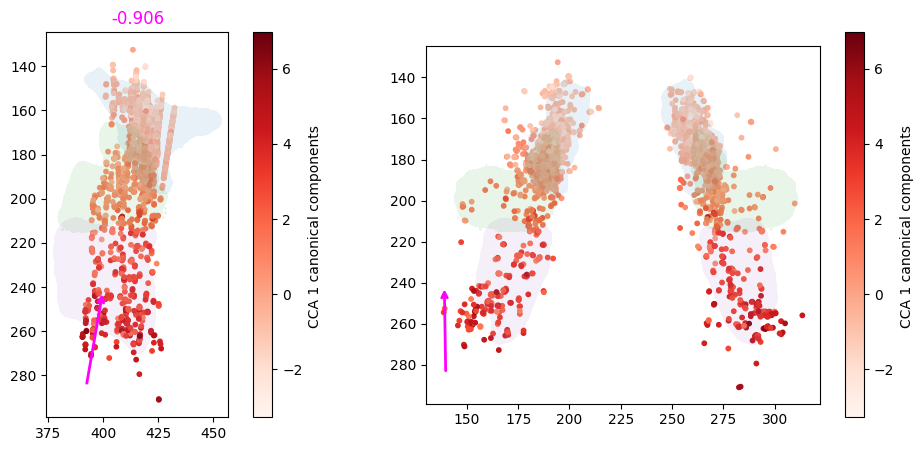

<Figure size 640x480 with 0 Axes>

In [124]:
k = 0
scale_factor =50 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * -scale_factor

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sca = plt.scatter(adata_mer_sm.obsm['spatial'][:, 0], adata_mer_sm.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()
plt.title("%.3f" %-canonical_correlations[k], color = 'magenta')

start_point = (np.min(adata_mer_sm.obsm['spatial'][:, 0]), np.max(adata_mer_sm.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[0], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )


plt.subplot(1,2,2)
sca = plt.scatter(adata_mer_sm.obsm['spatial'][:, 2], adata_mer_sm.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()

start_point = (np.min(adata_mer_sm.obsm['spatial'][:, 2]), np.max(adata_mer_sm.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[2], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )


plt.show()
plt.tight_layout()

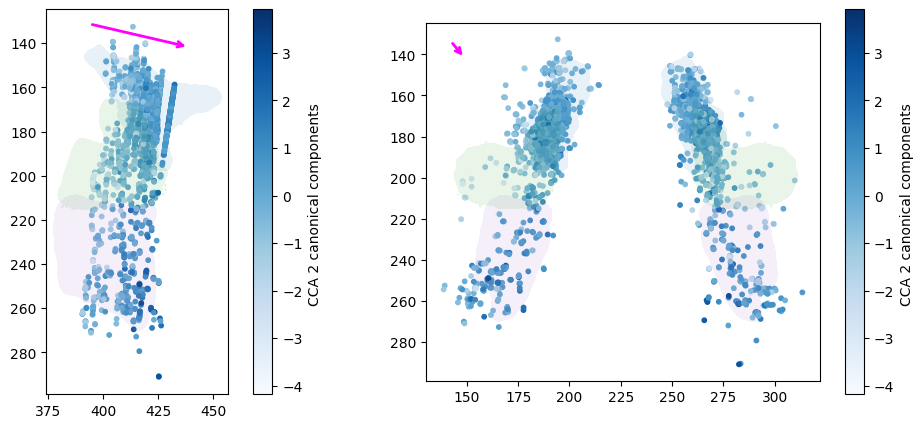

<Figure size 640x480 with 0 Axes>

In [126]:
k = 1
scale_factor = 50 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * scale_factor

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sca = plt.scatter(adata_mer_sm.obsm['spatial'][:, 0], adata_mer_sm.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')
plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()
start_point = (np.min(adata_mer_sm.obsm['spatial'][:, 0]), np.min(adata_mer_sm.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[0], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )



plt.subplot(1,2,2)
sca = plt.scatter(adata_mer_sm.obsm['spatial'][:, 2], adata_mer_sm.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.title("" %-canonical_correlations[k])
start_point = (np.min(adata_mer_sm.obsm['spatial'][:, 2]), np.min(adata_mer_sm.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[2], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )

plt.gca().invert_yaxis()

plt.show()
plt.tight_layout()

# it seems like its not the batch effect, 

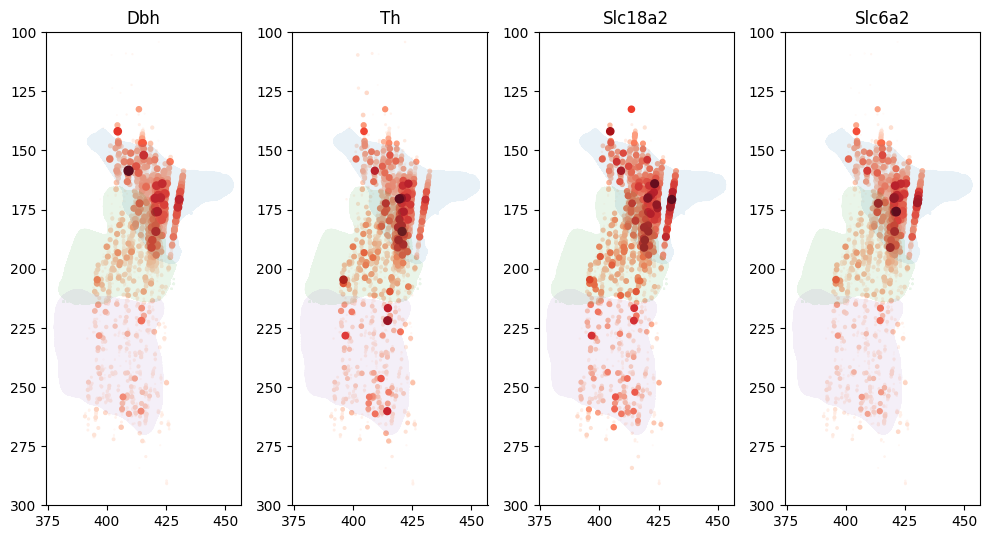

In [169]:
plt.figure(figsize = (10,6))
for i,genetarget in enumerate(['Dbh','Th','Slc18a2','Slc6a2']):

    expression_values = np.array(adata_mer[:,genetarget].X).flatten()
    plot_order = np.argsort(expression_values)
    expression_values = expression_values[plot_order]
    plt.subplot(1,4,i+1)
    plt.scatter(adata_mer.obs['x_CCF'][plot_order], adata_mer.obs['y_CCF'][plot_order], 
                c =expression_values, s=expression_values*.05, cmap = 'Reds')
    plt.gca().set_aspect('equal')
    plt.ylim(100,300)
    plt.gca().invert_yaxis()
    plt.title(genetarget)
    plt.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    plt.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    plt.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.tight_layout()

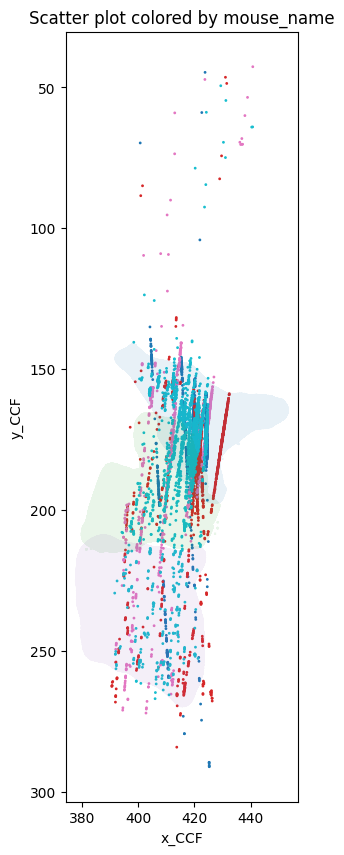

In [191]:
adata_mer.obs['mouse_name'] = adata_mer.obs['mouse_name'].astype('category')
# Convert categories to numeric codes
codes = adata_mer.obs['mouse_name'].cat.codes

# Create the scatter plot using the numeric codes and a colormap (e.g., 'viridis')
plt.figure(figsize = (10,10))
plt.scatter(adata_mer.obs['x_CCF'], adata_mer.obs['y_CCF'], s=1, c=codes, cmap='tab10')
plt.xlabel('x_CCF')
plt.ylabel('y_CCF')
plt.title('Scatter plot colored by mouse_name')
# plt.colorbar(label='Mouse Name Code')
plt.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()

In [192]:
codes

neuron_id
103685216640203968188516774531086347883    0
104587908325765086675948399347513609206    0
107556232960175669029944473037950900912    0
110143770882700220040132120043038831763    0
113385467015087615676147138608792183276    0
                                          ..
9623349862178950852359237543126573460      3
96245750577479322584616409396904825217     3
9744450250461526053237534442143333842      3
97921143935935429568316038856990191414     3
99055081123244552139194124219121354798     3
Length: 5473, dtype: int8

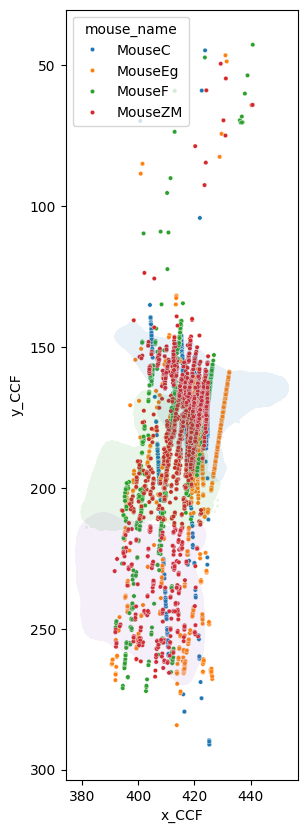

In [196]:
import seaborn as sns

# Combine the two coordinates into a DataFrame for convenience
import pandas as pd
df = pd.DataFrame({
    'x_CCF': adata_mer.obs['x_CCF'],
    'y_CCF': adata_mer.obs['y_CCF'],
    'mouse_name': adata_mer.obs['mouse_name']
})
plt.figure(figsize = (10,10))
# Create a scatter plot using Seaborn that automatically handles the hue
sns.scatterplot(data=df, x='x_CCF', y='y_CCF', hue='mouse_name', s=10)  # adjust s as needed
# plt.title('Scatter plot colored by mouse_name')
plt.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()

In [148]:
adata_mer_sm

View of AnnData object with n_obs × n_vars = 2651 × 315
    obs: 'slicename', 'x_CCF', 'y_CCF', 'z_CCF', 'totalcounts', 'mouse_name'
    obsm: 'spatial'

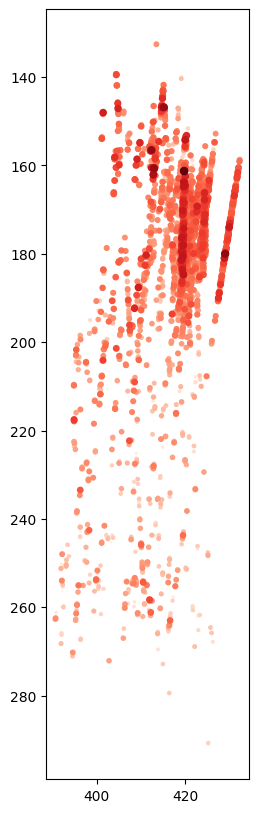

In [149]:
expression_values = np.array(adata_mer_sm[:,'Dbh'].X).flatten()
plot_order = np.argsort(expression_values)
expression_values = expression_values[plot_order]
plt.figure(figsize = (10,10))
plt.scatter(adata_mer_sm.obs['x_CCF'][plot_order], adata_mer_sm.obs['y_CCF'][plot_order], 
            c =expression_values, s=expression_values*100, cmap = 'Reds')
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()

In [150]:
adata_mer_sm.X.max()

array(0.34381551)

In [151]:
adata_mer.X.max()

0.6416791604197901